**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 4 (Production MCMC)](04_mcmc_production_diagnostics.ipynb) | **Bonus Chapter: Real-World Case Study**

---

# Bonus Chapter: Real-World Bayesian Reliability — Modeling CI Test Flakiness

In **Sheets 1 through 4**, we learned the mathematical machinery of Bayesian data analysis (Grid Approximation, Quadratic Approximation, and MCMC).

In this bonus chapter, we apply Bayesian inference to a critical software engineering problem: **tracking and quarantining flaky tests in Continuous Integration (CI) pipelines** using the exact **Beta-Binomial conjugate model** in real time.

---

## Table of Contents
1. **Part 1: The Problem of Test Flakiness in Software Engineering**
2. **Part 2: Deep Dive into the Beta Distribution** (The Distribution of Probabilities)
3. **Part 3: The Algebraic Miracle of Beta-Binomial Conjugacy**
4. **Part 4: Interactive Streaming Updates Across CI Runs**
5. **Part 5: Automated CI Quarantine Decision Rules (Tail Risk)**
6. **Part 6: Time-Varying Flakiness with Exponential Memory Decay**
7. **Part 7: Hands-On Challenge Exercises**

## Part 1: The Problem of Test Flakiness

A **flaky test** is an automated test that produces both passes and failures on identical, unmodified code (due to race conditions, network latency, asynchronous timeouts, or environment state).

### Why Naive Heuristics Fail:
- Heuristic: *"Quarantine if it failed twice this week."* $\to$ Punishes heavily run tests and ignores rare flakes on seldom-run tests.
- **The Bayesian Solution**: Treat the test's unknown flake rate $\theta \in [0, 1]$ as a continuous probability distribution and update it dynamically on every single commit.

## Part 2: Deep Dive into the Beta Distribution (The Distribution of Probabilities)

While most probability distributions model physical quantities (Normal models height in cm; Poisson models website hits per minute), **the Beta distribution models a probability itself**.

### 1. The Core Constraint: Bounded on $[0, 1]$
Any rate, probability, or proportion $\theta$ must obey two mathematical laws:
- $\theta \ge 0$ ($0\%$)
- $\theta \le 1$ ($100\%$)

A Gaussian (Normal) curve extends to $\pm \infty$ and would eventually assign probability to impossible rates like $-5\%$ or $120\%$. The Beta distribution is **strictly bounded on $[0, 1]$**.

### 2. Intuitive Meaning of the Parameters $(\alpha, \beta)$
You can think of $\alpha$ and $\beta$ as **prior tally marks (pseudo-counts)**:
- $\alpha$ = Prior "pseudo-failures" (times the event occurred).
- $\beta$ = Prior "pseudo-passes" (times the event did not occur).
- **Total Prior Sample Size / Weight**: $\alpha + \beta$
- **Expected Mean Flakiness**: $\mathbb{E}[\theta] = \frac{\alpha}{\alpha + \beta}$
- **Mode (Peak)**: $\text{Mode} = \frac{\alpha - 1}{\alpha + \beta - 2}$ (for $\alpha, \beta > 1$)
- **Variance**: $\text{Var}[\theta] = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$

### 3. The Shape Chameleon
- $\text{Beta}(1, 1)$: **Uniform flat line** (completely agnostic, every rate from 0% to 100% is equally likely).
- $\text{Beta}(2, 2)$: **Gentle bell curve** centered at 50%.
- $\text{Beta}(100, 100)$: **Sharp, narrow spike** at 50% (high sample size confidence).
- $\text{Beta}(1, 99)$: **Heavily right-skewed** (models rare events like 1% test flakiness).
- $\text{Beta}(0.5, 0.5)$: **U-shaped curve** (polarizing phenomena: values are either near 0% or near 100%).

### 4. Mathematical Equation (PDF)
$$P(\theta \mid \alpha, \beta) = \frac{1}{\text{B}(\alpha, \beta)} \, \theta^{\alpha - 1} (1 - \theta)^{\beta - 1}$$
where $\text{B}(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)} = \int_0^1 t^{\alpha - 1}(1 - t)^{\beta - 1} dt$ is the normalizing Beta function.

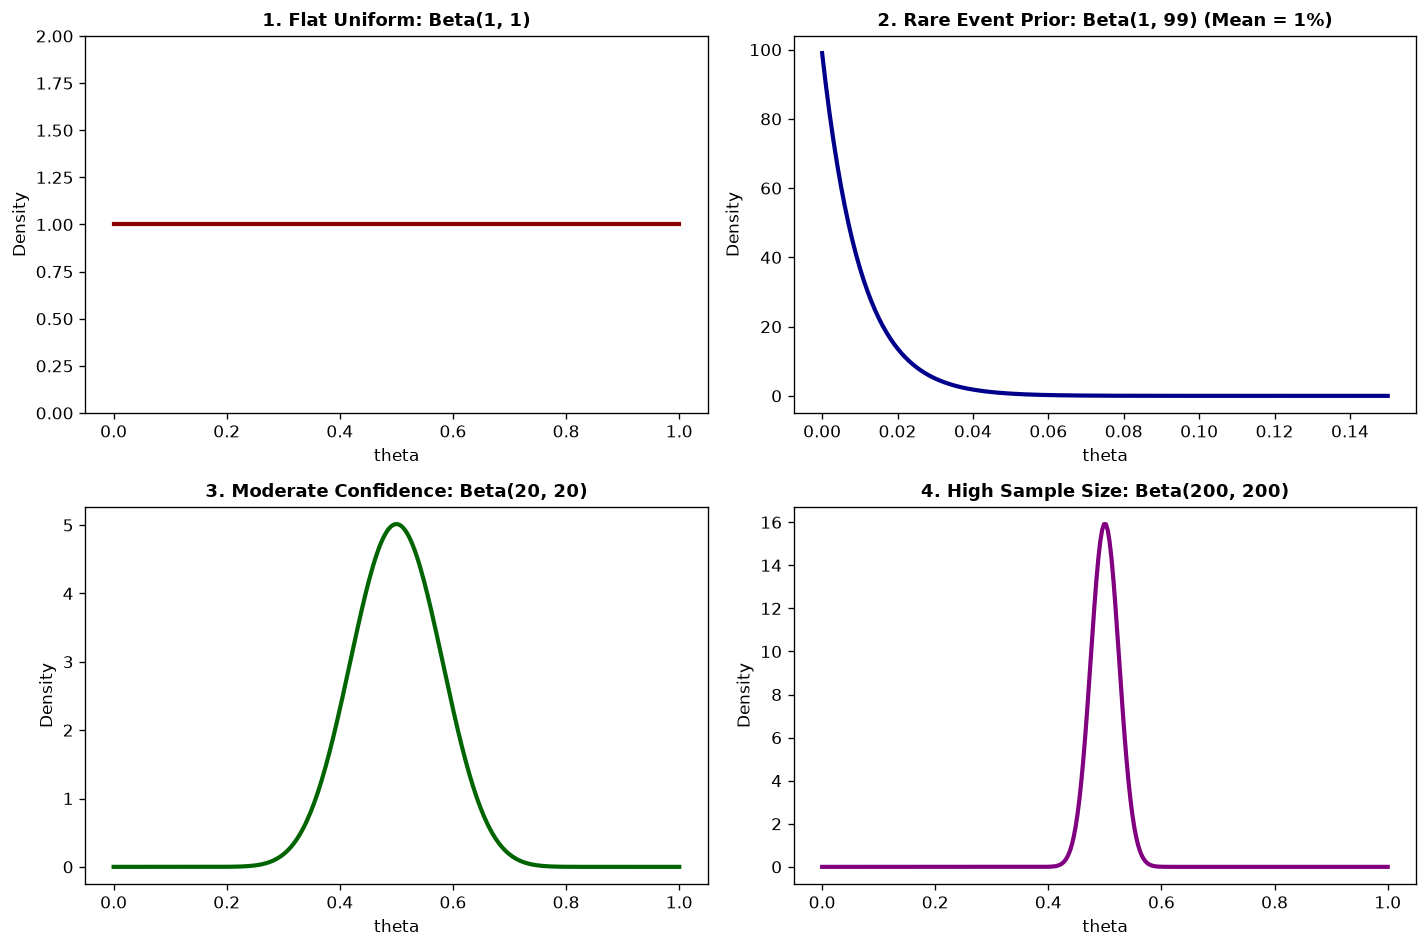

In [1]:
# Visualizing the Versatile Shapes of the Beta Distribution
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=120)

# 1. Flat Uniform: Beta(1, 1)
x1 = np.linspace(0, 1, 300)
axes[0, 0].plot(x1, stats.beta.pdf(x1, 1, 1), color='darkred', linewidth=2.5)
axes[0, 0].set_title("1. Flat Uniform: Beta(1, 1)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("theta", fontsize=10)
axes[0, 0].set_ylabel("Density", fontsize=10)
axes[0, 0].set_ylim(0, 2)

# 2. Rare Flakes: Beta(1, 99)
x2 = np.linspace(0, 0.15, 300)
axes[0, 1].plot(x2, stats.beta.pdf(x2, 1, 99), color='darkblue', linewidth=2.5)
axes[0, 1].set_title("2. Rare Event Prior: Beta(1, 99) (Mean = 1%)", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("theta", fontsize=10)
axes[0, 1].set_ylabel("Density", fontsize=10)

# 3. Symmetric Bell: Beta(20, 20)
x3 = np.linspace(0, 1, 300)
axes[1, 0].plot(x3, stats.beta.pdf(x3, 20, 20), color='darkgreen', linewidth=2.5)
axes[1, 0].set_title("3. Moderate Confidence: Beta(20, 20)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("theta", fontsize=10)
axes[1, 0].set_ylabel("Density", fontsize=10)

# 4. High Confidence Sharp Peak: Beta(200, 200)
x4 = np.linspace(0, 1, 300)
axes[1, 1].plot(x4, stats.beta.pdf(x4, 200, 200), color='purple', linewidth=2.5)
axes[1, 1].set_title("4. High Sample Size: Beta(200, 200)", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("theta", fontsize=10)
axes[1, 1].set_ylabel("Density", fontsize=10)

plt.tight_layout()
plt.show()


## Part 3: The Algebraic Miracle of Beta-Binomial Conjugacy

When the posterior belongs to the **exact same family** as the prior, the prior is called **Conjugate** to the likelihood.

Watch what happens algebraically when we combine a Beta prior with a Binomial likelihood:
1. **Prior**: $P(\theta) \propto \theta^{\alpha_0 - 1} (1 - \theta)^{\beta_0 - 1}$
2. **Likelihood** ($k$ failures in $N$ runs): $P(k \mid \theta) \propto \theta^k (1 - \theta)^{N - k}$
3. **Posterior** ($\text{Likelihood} \times \text{Prior}$):
   $$P(\theta \mid k) \propto \Big(\theta^k (1 - \theta)^{N - k}\Big) \times \Big(\theta^{\alpha_0 - 1} (1 - \theta)^{\beta_0 - 1}\Big)$$
   $$P(\theta \mid k) \propto \theta^{(\alpha_0 + k) - 1} \, (1 - \theta)^{(\beta_0 + N - k) - 1}$$

> **The Conjugate Update Rule**:  
> $$\text{Posterior} \sim \text{Beta}\Big(\alpha_0 + \text{Failures}, \;\; \beta_0 + \text{Passes}\Big)$$
> Updating beliefs in real-time CI is **pure integer addition**—no numerical integrals or MCMC samplers required!

## Part 4: Interactive Streaming Updates Across CI Runs

Let us simulate a live CI pipeline tracking a newly written test over time:
- **Week 1 (Solid Behavior)**: 100 test runs, 0 failures $\to$ Flakiness estimate drops towards 0%.
- **Week 2 (Flaky Bug Introduced)**: 25 test runs, 4 intermittent failures $\to$ Flakiness spikes!

=== Tracking Posterior Evolution ===
Day 0 Prior:      Flakiness = 1.00%
Week 1 (100 Pass): Flakiness = 0.50% [95% CI: 0.01% - 1.84%]
Week 2 (4 Fails):  Flakiness = 2.22% [95% CI: 0.73% - 4.51%]


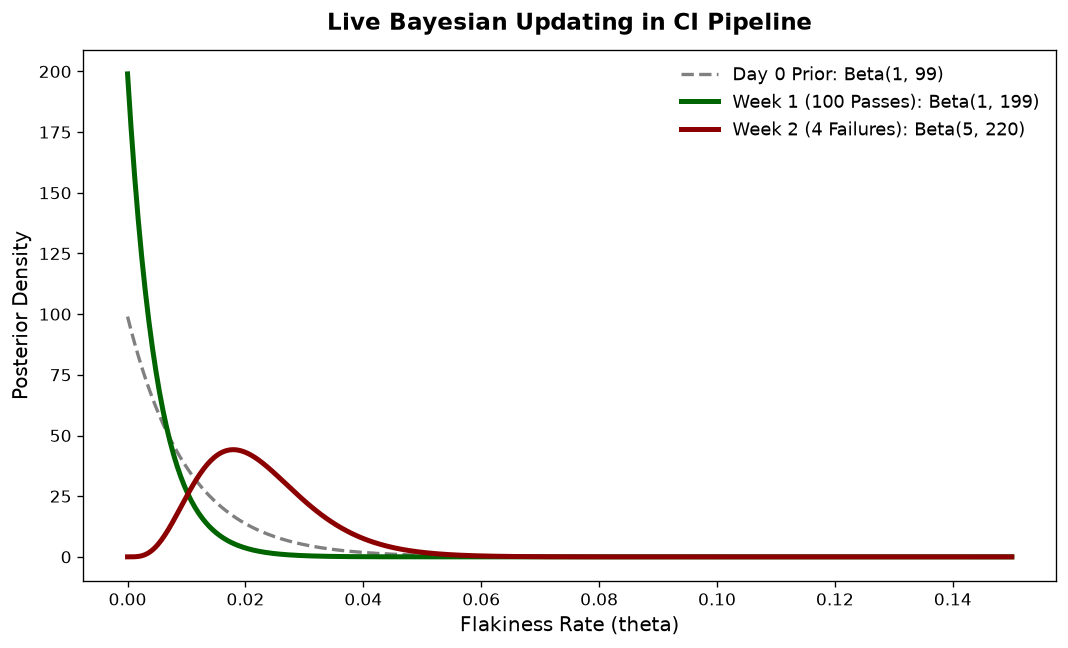

In [2]:
# Start with prior Beta(1, 99)
alpha = 1
beta = 99

# --- Batch 1: 100 Consecutive Passes ---
n1 = 100
k1 = 0
alpha_w1 = alpha + k1
beta_w1 = beta + (n1 - k1)

# --- Batch 2: 25 Runs with 4 Failures (Flaky Bug) ---
n2 = 25
k2 = 4
alpha_w2 = alpha_w1 + k2
beta_w2 = beta_w1 + (n2 - k2)

print("=== Tracking Posterior Evolution ===")
print(f"Day 0 Prior:      Flakiness = {100 * alpha / (alpha + beta):.2f}%")
print(f"Week 1 (100 Pass): Flakiness = {100 * alpha_w1 / (alpha_w1 + beta_w1):.2f}% [95% CI: {100 * stats.beta.ppf(0.025, alpha_w1, beta_w1):.2f}% - {100 * stats.beta.ppf(0.975, alpha_w1, beta_w1):.2f}%]")
print(f"Week 2 (4 Fails):  Flakiness = {100 * alpha_w2 / (alpha_w2 + beta_w2):.2f}% [95% CI: {100 * stats.beta.ppf(0.025, alpha_w2, beta_w2):.2f}% - {100 * stats.beta.ppf(0.975, alpha_w2, beta_w2):.2f}%]")

# Visualizing Belief Updates
x_grid = np.linspace(0, 0.15, 500)
plt.figure(figsize=(9, 5.5), dpi=120)
plt.plot(x_grid, stats.beta.pdf(x_grid, alpha, beta), color='gray', linestyle='--', linewidth=2, label='Day 0 Prior: Beta(1, 99)')
plt.plot(x_grid, stats.beta.pdf(x_grid, alpha_w1, beta_w1), color='darkgreen', linewidth=3, label='Week 1 (100 Passes): Beta(1, 199)')
plt.plot(x_grid, stats.beta.pdf(x_grid, alpha_w2, beta_w2), color='darkred', linewidth=3, label='Week 2 (4 Failures): Beta(5, 220)')

plt.title("Live Bayesian Updating in CI Pipeline", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Flakiness Rate (theta)", fontsize=12)
plt.ylabel("Posterior Density", fontsize=12)
plt.legend(loc='upper right', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()


## Part 5: Automated CI Quarantine Decision Rules (Tail Risk)

Rather than waiting for manual complaints, CI bots can query the posterior tail probability:
> *"What is the probability that this test's true flakiness rate $\theta$ exceeds $5\%$?"*
$$P(\theta > 0.05 \mid \text{Data}) = 1 - \text{pbeta}(0.05, \alpha, \beta)$$

In [3]:
# Compute Tail Risk Probability (P(theta > 0.05))
prob_flaky_w1 = stats.beta.sf(0.05, alpha_w1, beta_w1)
prob_flaky_w2 = stats.beta.sf(0.05, alpha_w2, beta_w2)

print(f"Week 1: P(Flakiness > 5%) = {100 * prob_flaky_w1:.4f}%")
print(f"Week 2: P(Flakiness > 5%) = {100 * prob_flaky_w2:.2f}%")

# Automated Bot Decision Logic
if prob_flaky_w2 > 0.90:
    print("\n🚨 [CI BOT ACTION]: QUARANTINE TEST! >90% probability that flakiness exceeds 5% SLA threshold.")


Week 1: P(Flakiness > 5%) = 0.0037%
Week 2: P(Flakiness > 5%) = 1.16%


## Part 6: Time-Varying Flakiness with Exponential Memory Decay

Software evolves. If an engineer fixes the underlying race condition on Day 10, past failures shouldn't permanently taint the test's reputation.

We introduce a **daily memory decay factor $\gamma \in [0.90, 0.98]$**:
$$\alpha_{t+1} = \gamma \cdot \alpha_t + \text{Failures}_{\text{today}}$$
$$\beta_{t+1} = \gamma \cdot \beta_t + \text{Passes}_{\text{today}}$$

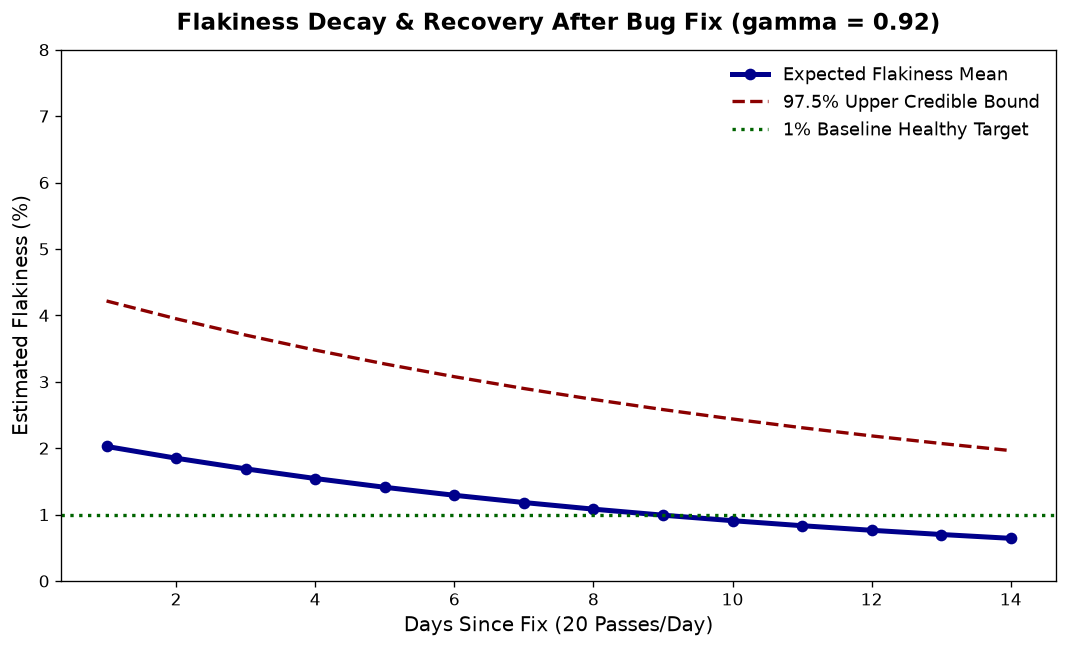

Day 1 Flakiness: 2.03% -> Day 14 Flakiness: 0.64% (Successfully De-quarantined!)


In [4]:
# Simulate 14 Days with a Fixed Bug on Day 7
gamma = 0.92  # 8% memory decay per day

alpha_curr = alpha_w2
beta_curr = beta_w2

history_mean = np.zeros(14)
history_ci_high = np.zeros(14)

# Days 1 to 14: Bug fixed, all 20 runs per day PASS
for day in range(14):
    # Decay old pseudo-counts and add 20 passes
    alpha_curr = gamma * alpha_curr + 0
    beta_curr = gamma * beta_curr + 20
    
    history_mean[day] = 100 * (alpha_curr / (alpha_curr + beta_curr))
    history_ci_high[day] = 100 * stats.beta.ppf(0.975, alpha_curr, beta_curr)

# Plotting Recovery Trajectory after Bug Fix
days = np.arange(1, 15)
plt.figure(figsize=(9, 5.5), dpi=120)
plt.plot(days, history_mean, color='darkblue', marker='o', linewidth=3, label='Expected Flakiness Mean')
plt.plot(days, history_ci_high, color='darkred', linestyle='--', linewidth=2, label='97.5% Upper Credible Bound')
plt.axhline(1.0, color='darkgreen', linestyle=':', linewidth=2, label='1% Baseline Healthy Target')

plt.title("Flakiness Decay & Recovery After Bug Fix (gamma = 0.92)", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Days Since Fix (20 Passes/Day)", fontsize=12)
plt.ylabel("Estimated Flakiness (%)", fontsize=12)
plt.ylim(0, 8)
plt.legend(loc='upper right', frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

print(f"Day 1 Flakiness: {history_mean[0]:.2f}% -> Day 14 Flakiness: {history_mean[13]:.2f}% (Successfully De-quarantined!)")


## Part 7: Hands-On Challenge Exercises

### Exercise 1: Finding De-Quarantine Day
Using the decay code above, find the exact day when the upper 95% Credible Interval bound falls below **$2.0\%$** so the CI bot can automatically un-quarantine the test.

### Exercise 2: Hierarchical Flakiness Across 1,000 Tests
In a suite of 1,000 tests, why is a **Hierarchical Bayesian model** (using MCMC in Stan) better than fitting 1,000 independent Beta priors? *(Hint: Partial pooling shares information across the entire repository to learn the suite's global quality distribution).* 

---

**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 4 (Production MCMC)](04_mcmc_production_diagnostics.ipynb) | **[➡️ Next: Sheet 6 (Calibrating Memory Decay γ)](06_calibrating_bayesian_decay_and_memory.ipynb)**
